# 04 — Threshold analysis and final test evaluation (baseline)

**Order of operations (enforced by the notebook structure):**
1. Select the model from Phase 5 cross-validation results (training set only).
2. Analyse thresholds on **out-of-fold** training predictions and choose one with a pre-stated rule.
3. **Lock** the model and threshold (written to `reports/locked_decisions_baseline.json`).
4. Only then load the test set and evaluate the locked pipeline **once**.

No hyperparameter tuning here (Phase 7). The test set does not influence any decision in this notebook.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from churn.config import FIGURES_DIR, REPORTS_DIR
from churn.data import load_dataset, split_features_target, split_train_test
from churn.evaluation import (
    bootstrap_metric_intervals,
    classification_metrics,
    confusion_at_threshold,
    select_threshold_min_recall,
    threshold_table,
)
from churn.modeling import cross_validate_models, make_baseline_pipeline

%matplotlib inline
pd.set_option("display.precision", 4)

TEXT, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": TEXT,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10, "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Model selection (from Phase 5 CV, training set only)

In [2]:
cv_summary = pd.read_csv(REPORTS_DIR / "cv_baseline_summary.csv", header=[0, 1], index_col=0)
cv_summary.xs("mean", axis=1, level=1)[["roc_auc", "pr_auc", "brier", "log_loss", "train_roc_auc"]]

,roc_auc,pr_auc,brier,log_loss,train_roc_auc
model,,,,,
LogisticRegression,0.8463,0.6612,0.1350,0.4169,0.8496
RandomForest,0.8263,0.6205,0.1438,0.4667,1.0000
HistGradientBoosting,0.8366,0.6499,0.1399,0.4352,0.9624


**Selected: Logistic Regression.** In Phase 5 it had the best mean ROC-AUC, PR-AUC, Brier score, and log loss, was better than both tree models in 14–15 of 15 paired folds, and showed almost no train/validation gap. HistGradientBoosting remains a candidate for tuning in Phase 7, but is **not** evaluated on the test set here, to keep test-set exposure to the single locked pipeline.

In [3]:
SELECTED_MODEL = "LogisticRegression"

train_df, _ = split_train_test(load_dataset())
X_train, y_train = split_features_target(train_df)
# The test half is discarded here and only re-created in section 4, after decisions are locked.

cv = cross_validate_models(X_train, y_train, model_names=[SELECTED_MODEL])

# Same seed and folds as Phase 5 -> identical results (reproducibility check).
phase5 = pd.read_csv(REPORTS_DIR / "cv_baseline_fold_metrics.csv").query("model == @SELECTED_MODEL")
assert np.allclose(cv.fold_metrics["roc_auc"].to_numpy(), phase5["roc_auc"].to_numpy())
print("Out-of-fold predictions reproduced from Phase 5:", len(cv.oof_predictions), "rows (3 repeats)")

Out-of-fold predictions reproduced from Phase 5: 16902 rows (3 repeats)


## 2. Threshold analysis (out-of-fold training predictions)

Each training customer has one out-of-fold probability per CV repeat. The table is computed per repeat and averaged, so the chosen threshold is not tuned to a single fold split.

In [4]:
per_repeat = [
    threshold_table(part["y_true"], part["proba"]).assign(repeat=repeat)
    for repeat, part in cv.oof_predictions.groupby("repeat")
]
per_repeat = pd.concat(per_repeat)
thresholds = per_repeat.groupby("threshold")[["precision", "recall", "f1", "predicted_positive_rate"]].mean().reset_index()
thresholds.to_csv(REPORTS_DIR / "threshold_analysis_baseline.csv", index=False)
thresholds.iloc[::5]

,threshold,precision,recall,f1,predicted_positive_rate
0,0.05,0.3531,0.9737,0.5183,0.7316
5,0.10,0.4001,0.9425,0.5618,0.6250
10,0.15,0.4379,0.9124,0.5918,0.5528
15,0.20,0.4757,0.8589,0.6123,0.4791
20,0.25,0.5106,0.8149,0.6278,0.4235
25,0.30,0.5423,0.7668,0.6353,0.3752
30,0.35,0.5699,0.7128,0.6334,0.3319
35,0.40,0.5956,0.6618,0.6270,0.2948
40,0.45,0.6245,0.5984,0.6112,0.2543
45,0.50,0.6537,0.5454,0.5946,0.2214


### Business context

- A **false negative** is a churner we did not flag: the customer leaves without any retention attempt, and their future revenue is lost.
- A **false positive** is a loyal customer we flagged: we spend a retention offer (discount, call-centre time) on someone who would have stayed.
- In most subscription businesses a lost customer costs more than a retention contact, so the operating point should lean towards **recall**, limited by how many customers the retention team can actually contact (the **predicted positive rate**).

If real costs were known, the threshold could be derived directly: with calibrated probabilities, contacting a customer is worthwhile when `p × (value saved if retained) × (offer success rate) > contact cost`, i.e. `threshold = contact cost / (value × success rate)`. **We do not have these numbers**, so we use an explicit, adjustable policy instead of inventing costs.

**Threshold rule (stated before looking at the results):** *choose the threshold with the highest precision among those that reach an out-of-fold recall of at least 0.75.* The 0.75 recall target is a **provisional business assumption** ("reach three out of four churners"), to be replaced once retention costs and capacity are known.

In [5]:
MIN_RECALL = 0.75
chosen_threshold = select_threshold_min_recall(thresholds, min_recall=MIN_RECALL)
f1_best = thresholds.loc[thresholds["f1"].idxmax(), "threshold"]

# Stability: apply the same rule to each CV repeat separately.
per_repeat_choice = {
    repeat: select_threshold_min_recall(part, MIN_RECALL) for repeat, part in per_repeat.groupby("repeat")
}
print(f"Chosen threshold (recall >= {MIN_RECALL}): {chosen_threshold:.2f}")
print(f"Per-repeat choices: {per_repeat_choice}")
print(f"For reference, F1-maximising threshold: {f1_best:.2f}")

thresholds.set_index("threshold").loc[[0.5, f1_best, chosen_threshold]].rename_axis("threshold")

Chosen threshold (recall >= 0.75): 0.31
Per-repeat choices: {0: 0.31, 1: 0.31, 2: 0.31}
For reference, F1-maximising threshold: 0.32


,precision,recall,f1,predicted_positive_rate
threshold,,,,
0.50,0.6537,0.5454,0.5946,0.2214
0.32,0.5540,0.7494,0.6370,0.3590
0.31,0.5476,0.7581,0.6359,0.3674


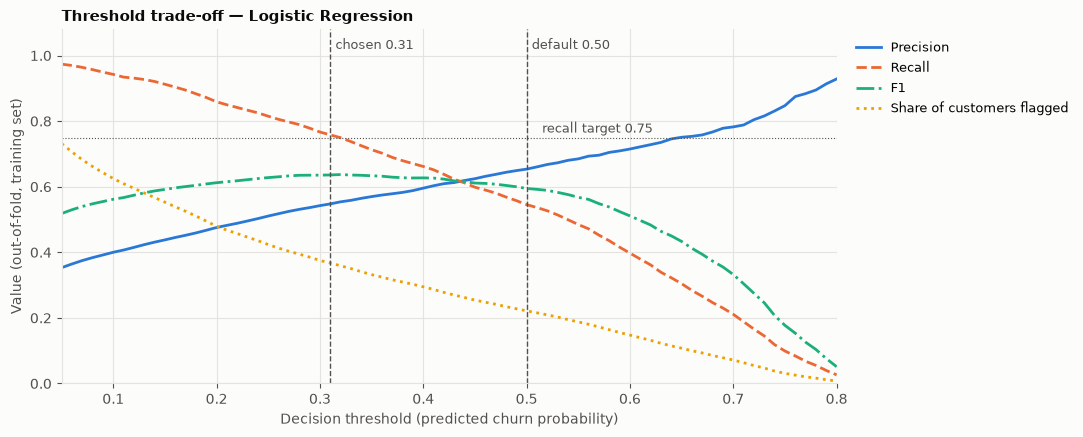

In [6]:
LINES = [  # (column, label, colour, line style)
    ("precision", "Precision", "#2a78d6", "-"),
    ("recall", "Recall", "#eb6834", "--"),
    ("f1", "F1", "#1baf7a", "-."),
    ("predicted_positive_rate", "Share of customers flagged", "#eda100", ":"),
]
# Above ~0.80 under 1% of customers are flagged, so precision there is noise; not plotted.
shown = thresholds[thresholds["threshold"] <= 0.80]
fig, ax = plt.subplots(figsize=(10, 4.6))
for col, label, color, style in LINES:
    ax.plot(shown["threshold"], shown[col], color=color, ls=style, lw=2, label=label)
for x, text in [(0.5, "default 0.50"), (chosen_threshold, f"chosen {chosen_threshold:.2f}")]:
    ax.axvline(x, color=MUTED, lw=1, ls="--")
    ax.text(x + 0.005, 1.02, text, color=MUTED, fontsize=9)
ax.axhline(MIN_RECALL, color=MUTED, lw=0.8, ls=":")
ax.text(0.515, MIN_RECALL + 0.015, f"recall target {MIN_RECALL:.2f}", color=MUTED, fontsize=9)
ax.set(xlim=(0.05, 0.80), ylim=(0, 1.08), xlabel="Decision threshold (predicted churn probability)",
       ylabel="Value (out-of-fold, training set)")
ax.set_title("Threshold trade-off — Logistic Regression")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9)
save(fig, "17_threshold_tradeoff")
plt.show()

## 3. Lock decisions

Written to disk **before** the test set is loaded, so the decisions are auditable.

In [7]:
cv_at_threshold = pd.DataFrame([
    classification_metrics(part["y_true"], part["proba"], chosen_threshold)
    for _, part in cv.oof_predictions.groupby("repeat")
])

locked = {
    "model": SELECTED_MODEL,
    "threshold": chosen_threshold,
    "threshold_rule": f"highest precision with out-of-fold recall >= {MIN_RECALL}",
    "selection_evidence": "Phase 5 repeated stratified 5-fold CV on the training set",
    "cv_metrics_at_threshold_mean": cv_at_threshold.mean().round(4).to_dict(),
}
(REPORTS_DIR / "locked_decisions_baseline.json").write_text(json.dumps(locked, indent=2))
locked

{'model': 'LogisticRegression',
 'threshold': 0.31,
 'threshold_rule': 'highest precision with out-of-fold recall >= 0.75',
 'selection_evidence': 'Phase 5 repeated stratified 5-fold CV on the training set',
 'cv_metrics_at_threshold_mean': {'roc_auc': 0.8456,
  'pr_auc': 0.6588,
  'precision': 0.5476,
  'recall': 0.7581,
  'f1': 0.6359,
  'brier': 0.135,
  'log_loss': 0.4169}}

## 4. Final evaluation on the untouched test set (run once)

The locked pipeline is fitted on the full training set, then scores the test set once.

In [8]:
train_df, test_df = split_train_test(load_dataset())
X_train, y_train = split_features_target(train_df)
X_test, y_test = split_features_target(test_df)
print(f"Test rows: {len(X_test)}, churn rate {y_test.mean():.2%}")

final_pipeline = make_baseline_pipeline(locked["model"]).fit(X_train, y_train)
test_proba = final_pipeline.predict_proba(X_test)[:, 1]
train_proba = final_pipeline.predict_proba(X_train)[:, 1]
threshold = locked["threshold"]

test_report = bootstrap_metric_intervals(y_test, test_proba, threshold, n_resamples=1000)
test_report.to_csv(REPORTS_DIR / "test_evaluation_baseline.csv")
test_report

Test rows: 1409, churn rate 26.54%


,estimate,lower,upper
roc_auc,0.8420,0.8204,0.8619
pr_auc,0.6335,0.5834,0.6865
precision,0.5293,0.4881,0.5696
recall,0.7487,0.7035,0.7922
f1,0.6202,0.5826,0.6555
brier,0.1381,0.1282,0.1488
log_loss,0.4204,0.3939,0.4496


Intervals are 95% percentile bootstrap intervals over test rows: they show how much the estimate could move from test-set sampling alone.

In [9]:
# Fold-level spread: metrics per CV fold at the locked threshold. This is the right yardstick for
# a test-vs-CV gap (pooling a whole repeat hides fold-to-fold variation).
fold_metrics_at_threshold = pd.DataFrame([
    classification_metrics(part["y_true"], part["proba"], threshold)
    for _, part in cv.oof_predictions.groupby("fold")
])

comparison = pd.DataFrame({
    "train (in-sample)": classification_metrics(y_train, train_proba, threshold),
    "CV mean (15 folds)": fold_metrics_at_threshold.mean(),
    "CV std (15 folds)": fold_metrics_at_threshold.std(),
    "test": classification_metrics(y_test, test_proba, threshold),
})
comparison["test − CV mean"] = comparison["test"] - comparison["CV mean (15 folds)"]
comparison["gap / CV std"] = comparison["test − CV mean"] / comparison["CV std (15 folds)"]
comparison

,train (in-sample),CV mean (15 folds),CV std (15 folds),test,test − CV mean,gap / CV std
roc_auc,0.8493,0.8463,0.0121,0.8420,-0.0043,-0.3559
pr_auc,0.6669,0.6612,0.0176,0.6335,-0.0277,-1.5745
precision,0.5530,0.5481,0.0156,0.5293,-0.0188,-1.2005
recall,0.7645,0.7581,0.0307,0.7487,-0.0094,-0.3063
f1,0.6418,0.6358,0.0141,0.6202,-0.0156,-1.1071
brier,0.1336,0.1350,0.0044,0.1381,0.0030,0.6889
log_loss,0.4127,0.4169,0.0136,0.4204,0.0035,0.2584


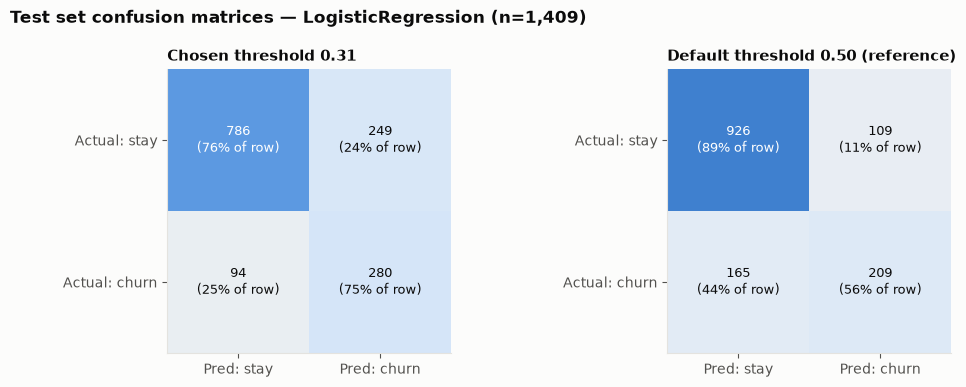

,TN,FP,FN,TP,flagged
Chosen threshold 0.31,786,249,94,280,529
Default threshold 0.50 (reference),926,109,165,209,318


In [10]:
cmap = LinearSegmentedColormap.from_list("blue_ramp", ["#f4f3f0", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
cm_rows = {}
for ax, (t, title) in zip(axes, [(threshold, f"Chosen threshold {threshold:.2f}"), (0.5, "Default threshold 0.50 (reference)")]):
    cm = confusion_at_threshold(y_test, test_proba, t)
    (tn, fp), (fn, tp) = cm
    cm_rows[title] = {"TN": tn, "FP": fp, "FN": fn, "TP": tp, "flagged": fp + tp}
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.sum())
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, f"{value:,}\n({value / cm[i].sum():.0%} of row)", ha="center", va="center",
                fontsize=9.5, color="white" if value > cm.sum() * 0.45 else TEXT)
    ax.set_xticks([0, 1], ["Pred: stay", "Pred: churn"])
    ax.set_yticks([0, 1], ["Actual: stay", "Actual: churn"])
    ax.grid(False)
    ax.set_title(title)
fig.suptitle(f"Test set confusion matrices — {locked['model']} (n={len(y_test):,})", x=0.01, ha="left",
             fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "18_test_confusion_matrices")
plt.show()
pd.DataFrame(cm_rows).T

## 5. Findings

**Locked before testing:** Logistic Regression (baseline, untuned), threshold **0.31** (highest precision with out-of-fold recall ≥ 0.75; the same threshold was chosen independently in all 3 CV repeats). The F1-maximising threshold (0.32) is almost identical, so the choice is not sensitive to the exact rule.

**Test set (n = 1,409, 374 churners), threshold 0.31:**
- ROC-AUC 0.842 [95% bootstrap CI 0.820–0.862], PR-AUC 0.634 [0.583–0.687].
- Recall 0.749 (280 of 374 churners flagged), precision 0.529, F1 0.620.
- 529 customers flagged (37.5%); about 1 in 2 flagged customers actually churns, vs. a 26.5% base rate.
- Brier 0.138, log loss 0.420.

**Threshold effect on the test set:** compared with 0.50, threshold 0.31 catches 71 more churners (280 vs. 209) at the cost of 140 more false alarms (249 vs. 109). Whether that trade is worth it depends on retention cost vs. customer value — the business input this rule stands in for.

**Generalization / overfitting:** train (in-sample), CV, and test agree closely. ROC-AUC 0.849 / 0.846 / 0.842. Every test − CV gap is within about 1.6 fold-level standard deviations, and the CV estimates fall inside the test bootstrap intervals. No sign of overfitting; the small test shortfall (largest for PR-AUC, −0.028) is consistent with sampling variation on a 1,409-row test set.

**Caveats:**
- The 0.75 recall target is a provisional business assumption, not a data-derived optimum.
- The test set has now been used once. Phase 7 must select any tuned model and threshold using training-set CV only; a later test evaluation of a tuned model will be a *second* look at the same data and should be reported as such.